# Actividad 1 — Regresión lineal
**Clase 4 · Aprendizaje Supervisado**

**Objetivo:** tomar un dataset con una variable objetivo continua y aplicar regresión lineal para predecirla a partir de las demás variables.

## Fuente de los datos

| | |
|---|---|
| **Organismo** | INDEC — Instituto Nacional de Estadística y Censos de la República Argentina |
| **Área responsable** | Dirección Nacional de Estadísticas Económicas |
| **Indicador** | Utilización de la capacidad instalada en la industria (UCII) |
| **Cuadro descargado** | "Utilización de la capacidad instalada en la industria, nivel general y bloques sectoriales. Años 2016-2026" |
| **Archivo** | `sh_capacidad_09_26.xls` (hoja "UCI - NG y bloques") |
| **Página de descarga** | https://www.indec.gob.ar/Nivel4/Tema/3/6/15 (Economía → Industria manufacturera → Utilización de la capacidad instalada → Series históricas) |
| **Enlace directo al archivo** | https://www.indec.gob.ar/ftp/cuadros/economia/sh_capacidad_09_26.xls |
| **Publicación** | Informe técnico del 15/09/2026 (último dato: julio de 2026) |
| **Fecha de descarga** | 27/09/2026 |
| **Informe técnico de referencia** | https://www.indec.gob.ar/uploads/informesdeprensa/capacidad_09_26CB3FA5C157.pdf |
| **Metodología** | https://www.indec.gob.ar/Nivel4/Tema/ftp/cuadros/economia/notas_metodologicas_capacidad_instalada_base2004.pdf |

**Qué mide:** la proporción (en %) de la capacidad productiva de la industria manufacturera que efectivamente se utiliza. Para calcularla, el INDEC considera la producción máxima que cada sector podría obtener con sus plantas actuales, usando el máximo de turnos posibles y descontando las paradas necesarias para mantenimiento. El relevamiento se hace sobre un panel de entre 600 y 700 empresas.

**Contenido:** datos mensuales de enero de 2016 a julio de 2026 (127 meses) del **nivel general** y de **12 bloques sectoriales**, expresados en porcentaje.

**Aclaraciones del propio INDEC que figuran en el archivo:**
- Los meses marcados con asterisco (por ejemplo `Enero*`) son **datos provisorios**, que pueden corregirse en publicaciones futuras.
- El bloque *Productos alimenticios y bebidas* no incluye la actividad vitivinícola ni los ingenios azucareros.
- El bloque *Sustancias y productos químicos* no incluye la industria farmacéutica.
- Los promedios pueden no coincidir exactamente por redondeo.

**Nota:** el INDEC reemplaza este archivo cada mes con el dato nuevo, y el nombre cambia según la fecha de publicación (`sh_capacidad_MM_AA.xls`). Para reproducir exactamente este análisis hay que usar la versión incluida en este repositorio.

**Cita:** INDEC (2026). *Utilización de la capacidad instalada en la industria, nivel general y bloques sectoriales. Años 2016-2026* [archivo xls]. Buenos Aires: Instituto Nacional de Estadística y Censos. Recuperado el 27/09/2026 de https://www.indec.gob.ar/Nivel4/Tema/3/6/15

## Planteo del problema

**Variable objetivo (continua):** la UCII del nivel general (%).
**Variables predictoras:** la UCII de cada bloque sectorial (%).

Método: 1) Preparación y organización de datos · 2) Exploración de los datos · 3) Modelado de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import sklearn.metrics as sm

## 1. Preparación y organización de datos
El archivo del INDEC está pensado para leerse en Excel, no para analizarse directamente: tiene títulos, filas vacías, una fila "Año 2016" que separa cada año, meses con asterisco (`Enero*` = dato provisorio) y notas al final. Hay que ordenarlo.

> Si al leer el archivo aparece un error que menciona `xlrd`, instalalo con `pip install xlrd` en la Terminal (se necesita para leer archivos `.xls` viejos).

In [2]:
# Archivo descargado del INDEC (ver sección "Fuente de los datos").
# Tiene que estar en la misma carpeta que esta notebook.
crudo = pd.read_excel("sh_capacidad_09_26.xls", header=None)
crudo.head(12)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Utilización de la capacidad instalada en la in...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Período,Nivel general,Productos alimenticios y bebidas,Productos del tabaco,Productos textiles,Papel y cartón,Edición e impresión,Refinación del petróleo,Sustancias y productos químicos,Productos de caucho y plástico,Productos minerales no metálicos,Industrias metálicas básicas,Industria automotriz,Metalmecánica excluida industria automotriz
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Porcentaje,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Año 2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Enero*,62.9,68.5,83.9,66.9,84.4,58.3,85.1,66.1,58.8,63.2,65.2,20.4,52.2


In [3]:
# Los nombres de las columnas están en la fila 2
columnas = list(crudo.iloc[2, 1:])
print(columnas)

['Nivel general', 'Productos alimenticios y bebidas', 'Productos del tabaco', 'Productos textiles', 'Papel y cartón', 'Edición e impresión', 'Refinación del petróleo', 'Sustancias y productos químicos', 'Productos de caucho y plástico', 'Productos minerales no metálicos', 'Industrias metálicas básicas', 'Industria automotriz', 'Metalmecánica excluida industria automotriz']


In [4]:
# Recorremos las filas: cuando aparece "Año XXXX" guardamos el año,
# y cada fila de mes la convertimos en una fecha junto con sus valores
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio",
         "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

filas = []
anio = None
for _, fila in crudo.iterrows():
    etiqueta = str(fila[0]).strip()
    if etiqueta.startswith("Año "):
        anio = int(etiqueta[4:])
    elif etiqueta.rstrip("*") in meses:
        mes = meses.index(etiqueta.rstrip("*")) + 1
        filas.append([pd.Timestamp(anio, mes, 1)] + list(fila[1:]))

df = pd.DataFrame(filas, columns=["fecha"] + columnas).set_index("fecha").astype(float)
df.head()

,Nivel general,Productos alimenticios y bebidas,Productos del tabaco,Productos textiles,Papel y cartón,Edición e impresión,Refinación del petróleo,Sustancias y productos químicos,Productos de caucho y plástico,Productos minerales no metálicos,Industrias metálicas básicas,Industria automotriz,Metalmecánica excluida industria automotriz
fecha,,,,,,,,,,,,,
2016-01-01,62.9,68.5,83.9,66.9,84.4,58.3,85.1,66.1,58.8,63.2,65.2,20.4,52.2
2016-02-01,64.2,66.8,81.3,72.2,79.0,53.6,86.8,66.8,53.6,73.1,70.7,43.1,51.1
2016-03-01,64.8,67.2,84.1,73.5,81.4,55.0,83.4,66.3,56.2,75.4,63.6,55.5,53.1
2016-04-01,64.8,63.5,81.4,74.4,83.8,58.5,82.0,67.9,60.2,75.4,65.2,54.6,53.2
2016-05-01,65.0,64.5,79.0,73.3,74.6,61.1,80.9,65.3,60.4,72.9,73.5,47.5,56.0


In [5]:
# Acortamos los nombres para que los gráficos se lean mejor
df.columns = ["nivel_general", "alimentos", "tabaco", "textiles", "papel",
              "edicion", "refinacion", "quimicos", "caucho_plastico",
              "minerales_no_met", "metalicas_basicas", "automotriz", "metalmecanica"]
df.head()

,nivel_general,alimentos,tabaco,textiles,papel,edicion,refinacion,quimicos,caucho_plastico,minerales_no_met,metalicas_basicas,automotriz,metalmecanica
fecha,,,,,,,,,,,,,
2016-01-01,62.9,68.5,83.9,66.9,84.4,58.3,85.1,66.1,58.8,63.2,65.2,20.4,52.2
2016-02-01,64.2,66.8,81.3,72.2,79.0,53.6,86.8,66.8,53.6,73.1,70.7,43.1,51.1
2016-03-01,64.8,67.2,84.1,73.5,81.4,55.0,83.4,66.3,56.2,75.4,63.6,55.5,53.1
2016-04-01,64.8,63.5,81.4,74.4,83.8,58.5,82.0,67.9,60.2,75.4,65.2,54.6,53.2
2016-05-01,65.0,64.5,79.0,73.3,74.6,61.1,80.9,65.3,60.4,72.9,73.5,47.5,56.0


In [6]:
print("Filas y columnas:", df.shape)
print("Desde", df.index.min().date(), "hasta", df.index.max().date())
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Filas y columnas: (127, 13)
Desde 2016-01-01 hasta 2026-07-01

Valores faltantes por columna:
nivel_general        0
alimentos            0
tabaco               0
textiles             0
papel                0
edicion              0
refinacion           0
quimicos             0
caucho_plastico      0
minerales_no_met     0
metalicas_basicas    0
automotriz           0
metalmecanica        0
dtype: int64


Quedan 127 meses completos, sin valores faltantes. Los datos están listos para explorar.

## 2. Exploración de los datos (AED)

In [7]:
df.describe().round(1)

,nivel_general,alimentos,tabaco,textiles,papel,edicion,refinacion,quimicos,caucho_plastico,minerales_no_met,metalicas_basicas,automotriz,metalmecanica
count,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0
mean,61.7,62.9,60.8,51.1,72.8,55.9,78.9,66.7,51.5,67.1,72.2,46.5,48.8
std,4.9,3.4,13.6,11.8,7.0,4.7,6.7,5.8,7.3,11.2,10.1,13.3,7.8
min,42.0,54.5,0.0,4.2,57.7,41.3,46.2,47.5,31.7,22.5,25.1,0.0,20.1
25%,58.4,60.2,50.8,43.4,67.8,52.9,75.8,63.7,46.4,59.1,66.3,39.0,43.5
50%,62.0,63.3,61.3,51.6,72.9,56.1,79.9,67.9,52.6,70.7,73.3,47.5,49.9
75%,65.0,65.3,71.1,58.9,77.4,59.2,83.6,70.8,56.8,75.4,80.2,55.6,54.7
max,69.6,70.2,97.1,74.4,91.8,65.9,89.9,77.0,65.8,83.8,89.6,74.3,63.2


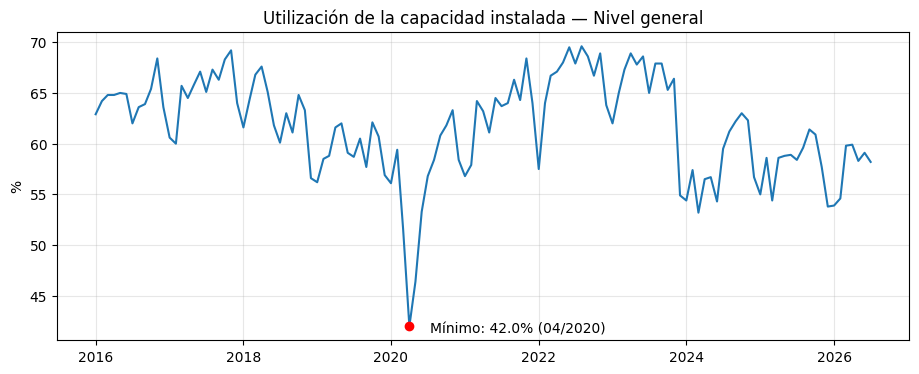

In [8]:
# Evolución del nivel general en el tiempo
plt.figure(figsize=(11, 4))
plt.plot(df.index, df["nivel_general"])
minimo = df["nivel_general"].idxmin()
plt.scatter(minimo, df.loc[minimo, "nivel_general"], color="red", zorder=3)
plt.annotate(f"Mínimo: {df.loc[minimo, 'nivel_general']}% ({minimo:%m/%Y})",
             (minimo, df.loc[minimo, "nivel_general"]), xytext=(15, -5), textcoords="offset points")
plt.title("Utilización de la capacidad instalada — Nivel general")
plt.ylabel("%")
plt.grid(alpha=0.3)
plt.show()

El valor más bajo de toda la serie es **abril de 2020 (42%)**, el primer mes completo de la cuarentena por COVID-19. Es un **valor atípico** real: no es un error de carga, sino un hecho excepcional.

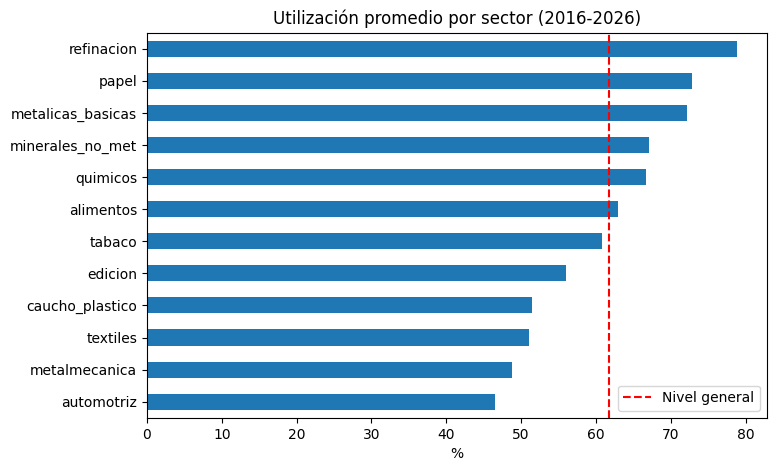

In [9]:
# Promedio de utilización de cada sector en todo el período
df.drop(columns="nivel_general").mean().sort_values().plot(kind="barh", figsize=(8, 5))
plt.axvline(df["nivel_general"].mean(), color="red", linestyle="--", label="Nivel general")
plt.title("Utilización promedio por sector (2016-2026)")
plt.xlabel("%")
plt.legend()
plt.show()

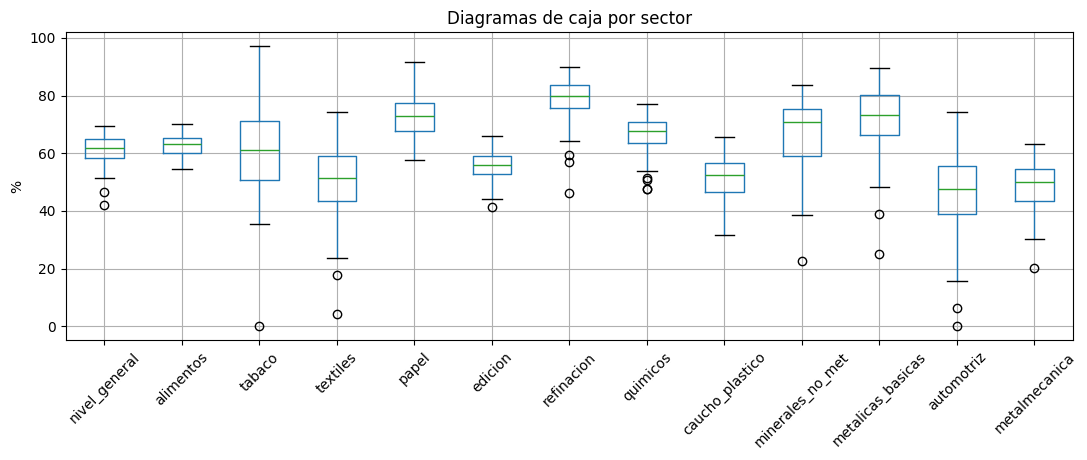

In [10]:
# Diagramas de caja: muestran la dispersión y los valores atípicos de cada sector
df.boxplot(figsize=(13, 4), rot=45)
plt.title("Diagramas de caja por sector")
plt.ylabel("%")
plt.show()

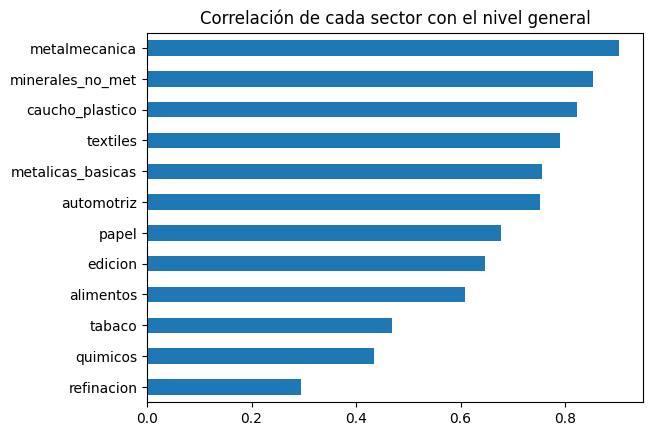

refinacion           0.29
quimicos             0.43
tabaco               0.47
alimentos            0.61
edicion              0.65
papel                0.68
automotriz           0.75
metalicas_basicas    0.75
textiles             0.79
caucho_plastico      0.82
minerales_no_met     0.85
metalmecanica        0.90
Name: nivel_general, dtype: float64

In [11]:
# ¿Qué sectores se mueven más parecido al nivel general?
correlaciones = df.corr()["nivel_general"].drop("nivel_general").sort_values()
correlaciones.plot(kind="barh")
plt.title("Correlación de cada sector con el nivel general")
plt.show()
correlaciones.round(2)

**Observaciones:**
- La refinación de petróleo y las industrias metálicas básicas son los sectores que más usan su capacidad; la industria automotriz y la metalmecánica, los que menos.
- La **metalmecánica** es el sector que más acompaña los movimientos del nivel general (correlación 0.90).
- La **refinación de petróleo** casi no se relaciona con el nivel general (0.29): funciona siempre alta, sin importar cómo le vaya al resto de la industria.
- La industria automotriz es la más variable (su caja es la más larga): tiene meses muy bajos, por ejemplo por vacaciones de planta o paradas de producción.

## 3. Creación de modelos de machine learning
Vamos a crear tres modelos de regresión lineal, de menor a mayor complejidad:

| Modelo | Variables predictoras | Para qué sirve |
|---|---|---|
| **Simple** | metalmecánica | Ver la recta en un gráfico 2D |
| **Con 2 variables** | metalmecánica + alimentos | Ver el plano en un gráfico 3D |
| **Múltiple** | los 12 sectores | Usar toda la información disponible |

Para cada uno seguimos los mismos pasos: entrenamiento → evaluación → residuos → predicciones y visualización.

### 3.1 División en entrenamiento y prueba
Separamos los datos **una sola vez** y usamos la misma división para todos los modelos, así podemos compararlos de forma justa:
- **Entrenamiento (80%)**: los meses con los que el modelo aprende.
- **Prueba (20%)**: meses que el modelo nunca vio, para comprobar si predice bien datos nuevos.

`random_state=42` hace que la división sea siempre la misma cada vez que se corre la notebook.

In [12]:
y = df["nivel_general"]
X = df.drop(columns="nivel_general")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Meses de entrenamiento:", len(X_train))
print("Meses de prueba:", len(X_test))

Meses de entrenamiento: 101
Meses de prueba: 26


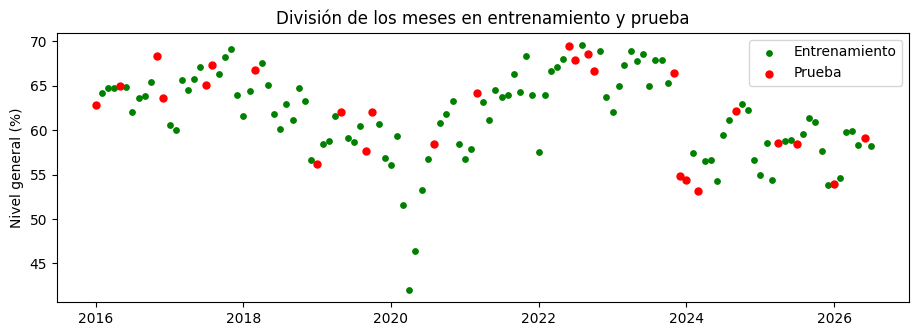

In [13]:
# ¿Qué meses quedaron en cada grupo? Los vemos sobre la serie completa
plt.figure(figsize=(11, 3.5))
plt.scatter(y_train.index, y_train, s=15, label="Entrenamiento", color="green")
plt.scatter(y_test.index, y_test, s=25, label="Prueba", color="red")
plt.title("División de los meses en entrenamiento y prueba")
plt.ylabel("Nivel general (%)")
plt.legend()
plt.show()

Definimos dos funciones que vamos a reutilizar con cada modelo:
- `mostrar_metricas`: calcula las métricas de evaluación vistas en clase.
- `calcular_residuos`: calcula el **residuo** de cada mes, es decir, la diferencia entre el valor real y el que predijo el modelo:

$$\text{residuo} = y_{real} - y_{predicho}$$

Un residuo positivo significa que el modelo predijo **menos** de lo real; uno negativo, que predijo **de más**.

In [14]:
def mostrar_metricas(y_real, y_pred):
    print("Error absoluto medio (MAE) =", round(sm.mean_absolute_error(y_real, y_pred), 3))
    print("Error cuadrático medio (MSE) =", round(sm.mean_squared_error(y_real, y_pred), 3))
    print("Error absoluto mediana =", round(sm.median_absolute_error(y_real, y_pred), 3))
    print("Puntuación de varianza explicada =", round(sm.explained_variance_score(y_real, y_pred), 3))
    print("Puntuación R2 =", round(sm.r2_score(y_real, y_pred), 3))

def calcular_residuos(y_real, y_pred):
    tabla = pd.DataFrame({"real": y_real, "predicho": y_pred.round(2)})
    tabla["residuo"] = (tabla["real"] - tabla["predicho"]).round(2)
    return tabla.sort_index()

def graficar_residuos(tabla, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(tabla["predicho"], tabla["residuo"])
    ax[0].axhline(0, color="black", linestyle="--")
    ax[0].set_xlabel("Valor predicho (%)"); ax[0].set_ylabel("Residuo")
    ax[0].set_title("Residuos vs valores predichos")
    ax[1].hist(tabla["residuo"], bins=10, edgecolor="black")
    ax[1].axvline(0, color="black", linestyle="--")
    ax[1].set_xlabel("Residuo"); ax[1].set_ylabel("Cantidad de meses")
    ax[1].set_title("Distribución de los residuos")
    fig.suptitle(titulo)
    plt.show()

### 3.2 Modelo 1: regresión lineal simple (metalmecánica)
Usamos una sola variable, la más correlacionada con el nivel general.

#### Entrenamiento

In [15]:
modelo_simple = linear_model.LinearRegression()
modelo_simple.fit(X_train[["metalmecanica"]], y_train)

print("Pendiente (alfa):", round(modelo_simple.coef_[0], 3))
print("Ordenada al origen (beta):", round(modelo_simple.intercept_, 3))
print(f"Ecuación: nivel_general = {modelo_simple.coef_[0]:.3f} * metalmecanica + {modelo_simple.intercept_:.3f}")

Pendiente (alfa): 0.576
Ordenada al origen (beta): 33.522
Ecuación: nivel_general = 0.576 * metalmecanica + 33.522


#### Evaluación

In [16]:
pred_simple = modelo_simple.predict(X_test[["metalmecanica"]])
mostrar_metricas(y_test, pred_simple)

Error absoluto medio (MAE) = 1.844
Error cuadrático medio (MSE) = 4.266
Error absoluto mediana = 1.679
Puntuación de varianza explicada = 0.83
Puntuación R2 = 0.828


#### Cálculo de residuos

In [17]:
residuos_simple = calcular_residuos(y_test, pred_simple)
residuos_simple

,real,predicho,residuo
fecha,,,
2016-01-01,62.9,63.60,-0.70
2016-05-01,65.0,65.79,-0.79
2016-11-01,68.4,66.48,1.92
2016-12-01,63.6,65.04,-1.44
2017-07-01,65.1,67.63,-2.53
2017-08-01,67.3,68.73,-1.43
2018-03-01,66.8,64.81,1.99
2019-01-01,56.2,55.65,0.55
2019-05-01,62.0,62.28,-0.28


Residuo promedio: 0.249
Mayor error por exceso (predijo de más): -3.36 en 07/2025
Mayor error por defecto (predijo de menos): 3.89 en 11/2023


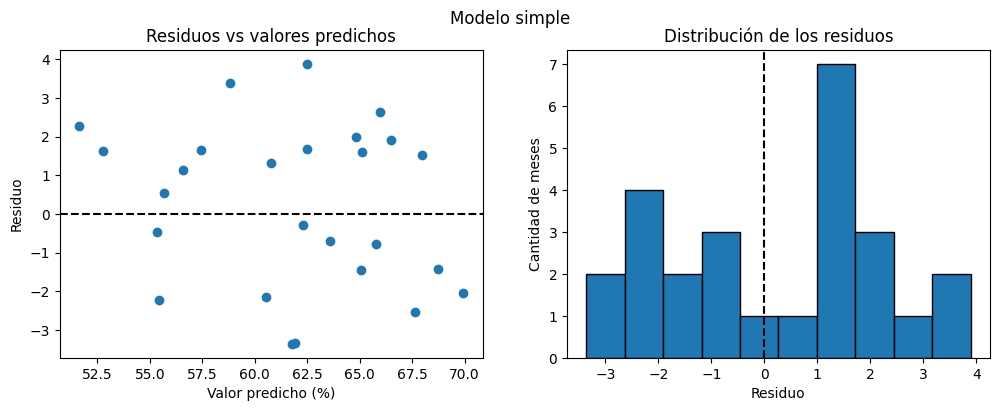

In [18]:
print("Residuo promedio:", round(residuos_simple["residuo"].mean(), 3))
print("Mayor error por exceso (predijo de más):", residuos_simple["residuo"].min(), "en", residuos_simple["residuo"].idxmin().strftime("%m/%Y"))
print("Mayor error por defecto (predijo de menos):", residuos_simple["residuo"].max(), "en", residuos_simple["residuo"].idxmax().strftime("%m/%Y"))
graficar_residuos(residuos_simple, "Modelo simple")

Los residuos se reparten alrededor de 0, sin un patrón claro: el modelo no se equivoca siempre para el mismo lado. Aun así, hay meses con errores de varios puntos porcentuales, porque la metalmecánica sola no explica todo el nivel general.

#### Predicciones y visualización 2D

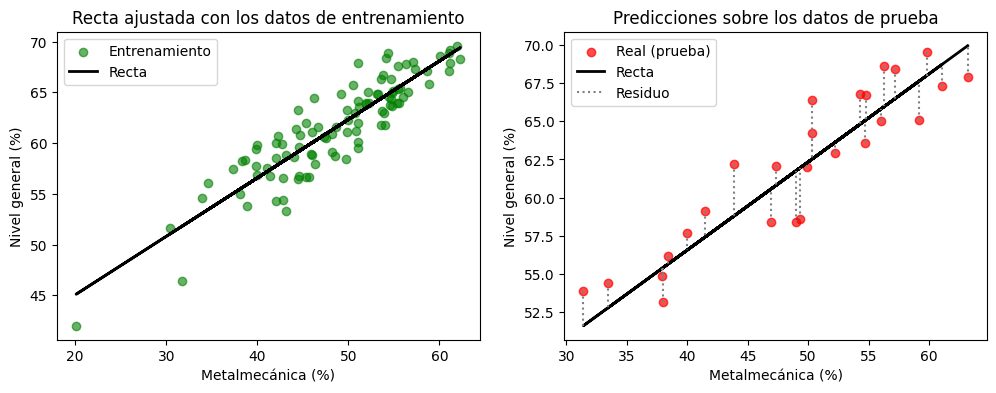

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(X_train["metalmecanica"], y_train, color="green", alpha=0.6, label="Entrenamiento")
ax[0].plot(X_train["metalmecanica"], modelo_simple.predict(X_train[["metalmecanica"]]), color="black", linewidth=2, label="Recta")
ax[0].set_title("Recta ajustada con los datos de entrenamiento")

ax[1].scatter(X_test["metalmecanica"], y_test, color="red", alpha=0.7, label="Real (prueba)")
ax[1].plot(X_test["metalmecanica"], pred_simple, color="black", linewidth=2, label="Recta")
# Líneas verticales = residuos
ax[1].vlines(X_test["metalmecanica"], y_test, pred_simple, color="gray", linestyle=":", label="Residuo")
ax[1].set_title("Predicciones sobre los datos de prueba")

for eje in ax:
    eje.set_xlabel("Metalmecánica (%)"); eje.set_ylabel("Nivel general (%)"); eje.legend()
plt.show()

En el gráfico de la derecha, cada línea punteada gris es un **residuo**: la distancia entre el valor real y la recta.

In [20]:
# Predicción de un caso nuevo: ¿qué nivel general esperamos si la metalmecánica usa el 45% de su capacidad?
caso = pd.DataFrame({"metalmecanica": [45]})
print("Predicción del nivel general:", round(modelo_simple.predict(caso)[0], 1), "%")

Predicción del nivel general: 59.5 %


### 3.3 Modelo 2: regresión con dos variables (metalmecánica + alimentos) — visualización 3D
Con dos variables predictoras el modelo ya no es una recta sino un **plano**:

$$nivel\_general = a_1 \cdot metalmecanica + a_2 \cdot alimentos + b$$

Elegimos alimentos porque es el sector de mayor peso en la industria, y metalmecánica porque es el más correlacionado. Con dos variables todavía podemos dibujarlo, en un gráfico 3D.

#### Entrenamiento

In [21]:
variables_3d = ["metalmecanica", "alimentos"]
modelo_2var = linear_model.LinearRegression()
modelo_2var.fit(X_train[variables_3d], y_train)

a1, a2 = modelo_2var.coef_
b = modelo_2var.intercept_
print(f"Ecuación: nivel_general = {a1:.3f} * metalmecanica + {a2:.3f} * alimentos + {b:.3f}")

Ecuación: nivel_general = 0.527 * metalmecanica + 0.227 * alimentos + 21.687


#### Evaluación

In [22]:
pred_2var = modelo_2var.predict(X_test[variables_3d])
mostrar_metricas(y_test, pred_2var)

Error absoluto medio (MAE) = 1.665
Error cuadrático medio (MSE) = 3.49
Error absoluto mediana = 1.62
Puntuación de varianza explicada = 0.86
Puntuación R2 = 0.859


#### Cálculo de residuos

Residuo promedio: 0.172
Residuo máximo (en valor absoluto): 3.88


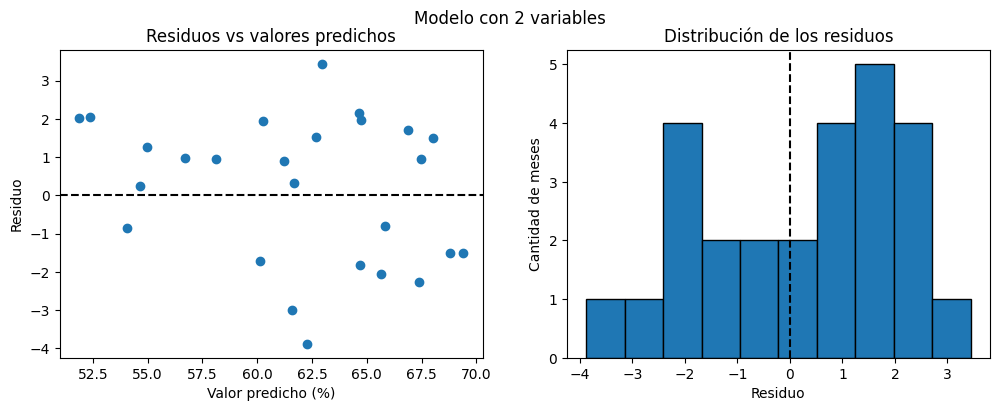

In [23]:
residuos_2var = calcular_residuos(y_test, pred_2var)
print("Residuo promedio:", round(residuos_2var["residuo"].mean(), 3))
print("Residuo máximo (en valor absoluto):", residuos_2var["residuo"].abs().max())
graficar_residuos(residuos_2var, "Modelo con 2 variables")

#### Predicciones y visualización 3D

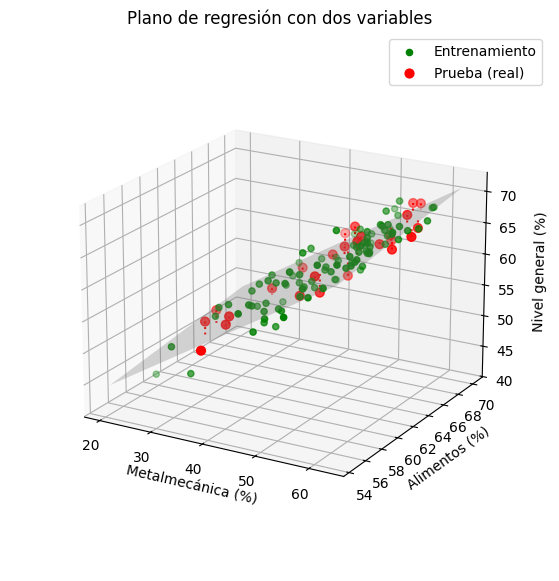

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # necesario para gráficos 3D

# Malla de puntos para dibujar el plano del modelo
mm = np.linspace(X["metalmecanica"].min(), X["metalmecanica"].max(), 20)
al = np.linspace(X["alimentos"].min(), X["alimentos"].max(), 20)
MM, AL = np.meshgrid(mm, al)
plano = a1 * MM + a2 * AL + b

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(MM, AL, plano, alpha=0.3, color="gray")
ax.scatter(X_train["metalmecanica"], X_train["alimentos"], y_train, color="green", label="Entrenamiento")
ax.scatter(X_test["metalmecanica"], X_test["alimentos"], y_test, color="red", s=40, label="Prueba (real)")
# Residuos: línea vertical desde cada punto de prueba hasta el plano
for x1, x2, real, pred in zip(X_test["metalmecanica"], X_test["alimentos"], y_test, pred_2var):
    ax.plot([x1, x1], [x2, x2], [real, pred], color="red", linestyle=":")
ax.set_xlabel("Metalmecánica (%)")
ax.set_ylabel("Alimentos (%)")
ax.set_zlabel("Nivel general (%)", labelpad=8)
ax.set_box_aspect(None, zoom=0.85)  # achica un poco el cubo para que entren las etiquetas
ax.set_title("Plano de regresión con dos variables")
ax.view_init(elev=20, azim=-60)
ax.legend()
plt.show()

El plano gris es el modelo. Los puntos rojos son los meses de prueba, y las líneas punteadas rojas son sus residuos (la distancia vertical hasta el plano). Cuanto más cerca del plano están los puntos, mejor predice el modelo.

> Tip: si en Jupyter escribís `%matplotlib notebook` (o `%matplotlib widget`) al principio de la celda, podés girar el gráfico 3D con el mouse.

In [25]:
# Predicción de un caso nuevo
caso = pd.DataFrame({"metalmecanica": [45], "alimentos": [65]})
print("Con metalmecánica al 45% y alimentos al 65%, el nivel general predicho es:",
      round(modelo_2var.predict(caso)[0], 1), "%")

Con metalmecánica al 45% y alimentos al 65%, el nivel general predicho es: 60.1 %


### 3.4 Modelo 3: regresión lineal múltiple (los 12 sectores)

#### Entrenamiento

In [26]:
modelo_multi = linear_model.LinearRegression()
modelo_multi.fit(X_train, y_train)
print("Ordenada al origen:", round(modelo_multi.intercept_, 3))

Ordenada al origen: 0.096


#### Evaluación

In [27]:
pred_multi = modelo_multi.predict(X_test)
mostrar_metricas(y_test, pred_multi)

Error absoluto medio (MAE) = 0.027
Error cuadrático medio (MSE) = 0.001
Error absoluto mediana = 0.023
Puntuación de varianza explicada = 1.0
Puntuación R2 = 1.0


#### Cálculo de residuos

Residuo máximo (en valor absoluto): 0.05 puntos porcentuales


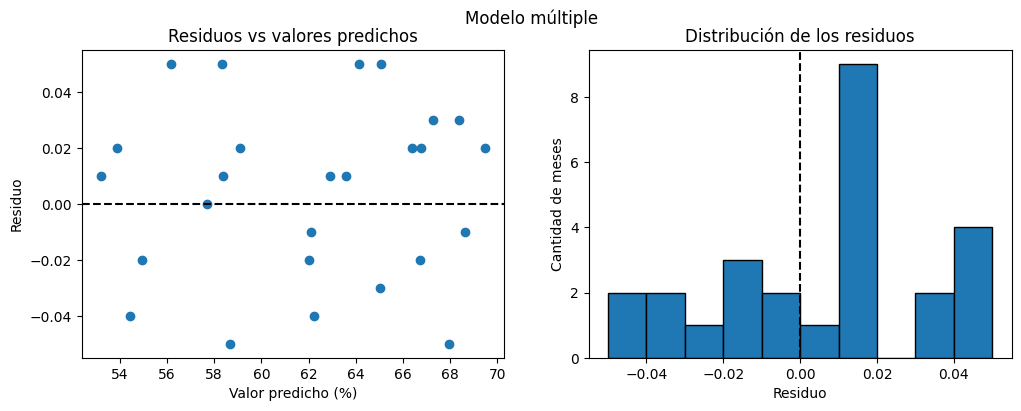

,real,predicho,residuo
fecha,,,
2016-01-01,62.9,62.89,0.01
2016-05-01,65.0,65.03,-0.03
2016-11-01,68.4,68.37,0.03
2016-12-01,63.6,63.59,0.01
2017-07-01,65.1,65.05,0.05
2017-08-01,67.3,67.27,0.03
2018-03-01,66.8,66.78,0.02
2019-01-01,56.2,56.15,0.05
2019-05-01,62.0,62.02,-0.02


In [28]:
residuos_multi = calcular_residuos(y_test, pred_multi)
print("Residuo máximo (en valor absoluto):", residuos_multi["residuo"].abs().max(), "puntos porcentuales")
graficar_residuos(residuos_multi, "Modelo múltiple")
residuos_multi.head(10)

Los residuos son de **centésimas** de punto: prácticamente se deben solo al redondeo de las cifras que publica el INDEC.

¿Por qué es tan preciso? Porque el INDEC calcula el nivel general como un **promedio ponderado** de los sectores: cada sector "pesa" según su tamaño en la industria. La regresión lineal descubre esos pesos a partir de los datos:

Suma de los coeficientes: 0.999


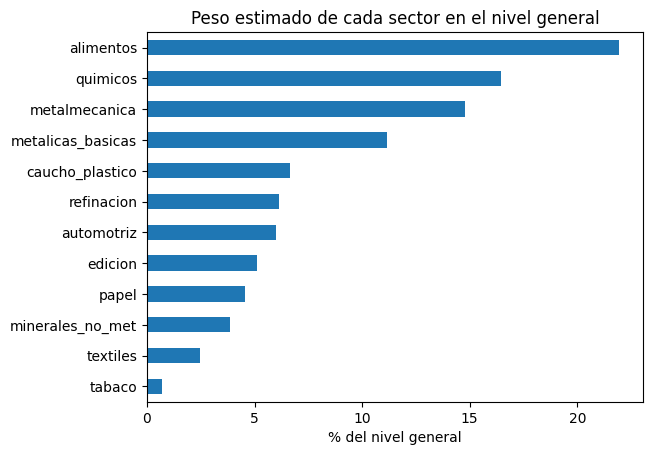

tabaco                0.7
textiles              2.5
minerales_no_met      3.9
papel                 4.6
edicion               5.1
automotriz            6.0
refinacion            6.1
caucho_plastico       6.7
metalicas_basicas    11.1
metalmecanica        14.8
quimicos             16.5
alimentos            22.0
dtype: float64

In [29]:
pesos = pd.Series(modelo_multi.coef_, index=X.columns).sort_values()
print("Suma de los coeficientes:", round(pesos.sum(), 3))

(pesos * 100).plot(kind="barh")
plt.title("Peso estimado de cada sector en el nivel general")
plt.xlabel("% del nivel general")
plt.show()
(pesos * 100).round(1)

Los coeficientes suman casi exactamente 1 y la ordenada al origen es casi 0: el modelo reconstruyó un promedio ponderado. Según el modelo, **alimentos y bebidas** es el sector de mayor peso (alrededor de 22%), seguido de **químicos** y **metalmecánica**.

#### Predicciones y visualización 2D

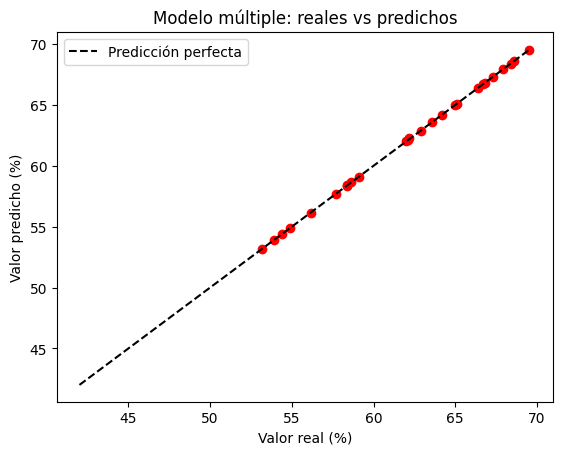

In [30]:
plt.scatter(y_test, pred_multi, color="red")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", label="Predicción perfecta")
plt.xlabel("Valor real (%)"); plt.ylabel("Valor predicho (%)")
plt.title("Modelo múltiple: reales vs predichos")
plt.legend()
plt.show()

### 3.5 Comparación de los tres modelos
Juntamos las métricas y comparamos las predicciones de los tres modelos mes a mes.

In [31]:
comparacion = pd.DataFrame({
    modelo: {"MAE": sm.mean_absolute_error(y_test, pred),
             "MSE": sm.mean_squared_error(y_test, pred),
             "Varianza explicada": sm.explained_variance_score(y_test, pred),
             "R2": sm.r2_score(y_test, pred)}
    for modelo, pred in [("Simple (1 var.)", pred_simple),
                         ("2 variables", pred_2var),
                         ("Múltiple (12 var.)", pred_multi)]
}).T.round(3)
comparacion

,MAE,MSE,Varianza explicada,R2
Simple (1 var.),1.844,4.266,0.83,0.828
2 variables,1.665,3.490,0.86,0.859
Múltiple (12 var.),0.027,0.001,1.00,1.000


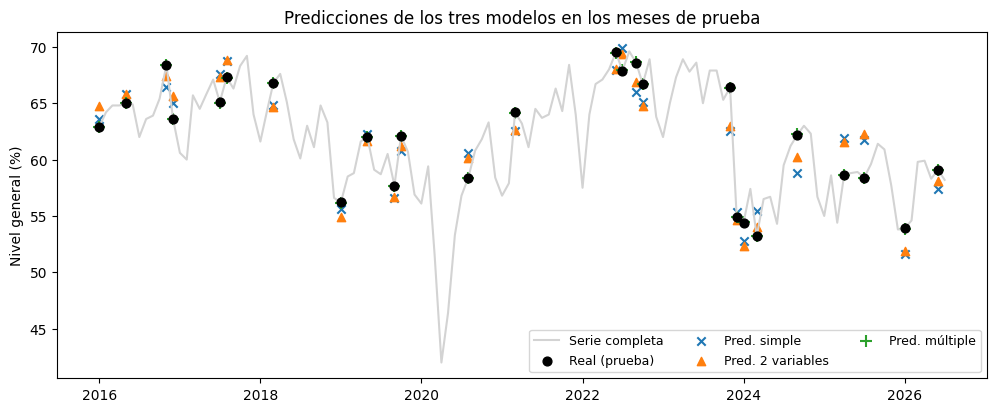

In [32]:
# Predicciones de los tres modelos sobre los meses de prueba, en orden cronológico
orden = np.argsort(y_test.index)
fechas = y_test.index[orden]

plt.figure(figsize=(12, 4.5))
plt.plot(df.index, df["nivel_general"], color="lightgray", label="Serie completa")
plt.scatter(fechas, y_test.values[orden], color="black", s=40, label="Real (prueba)", zorder=3)
plt.scatter(fechas, pred_simple[orden], marker="x", label="Pred. simple")
plt.scatter(fechas, pred_2var[orden], marker="^", label="Pred. 2 variables")
plt.scatter(fechas, pred_multi[orden], marker="+", s=80, label="Pred. múltiple")
plt.ylabel("Nivel general (%)")
plt.title("Predicciones de los tres modelos en los meses de prueba")
plt.legend(ncol=3, fontsize=9)
plt.show()

### 3.6 Regresión contraída (Ridge)
Ridge agrega una penalización λ (en scikit-learn se llama `alpha`) que "contrae" los coeficientes para que los valores aislados, como abril de 2020, influyan menos. La aplicamos sobre el modelo múltiple:

In [33]:
for alpha in [0.1, 1, 10, 100]:
    ridge = linear_model.Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    print(f"Ridge alpha={alpha:>5} -> R2 = {sm.r2_score(y_test, ridge.predict(X_test)):.5f}")

Ridge alpha=  0.1 -> R2 = 0.99996
Ridge alpha=    1 -> R2 = 0.99996
Ridge alpha=   10 -> R2 = 0.99995
Ridge alpha=  100 -> R2 = 0.99937


In [34]:
ridge = linear_model.Ridge(alpha=1)
ridge.fit(X_train, y_train)
mostrar_metricas(y_test, ridge.predict(X_test))

Error absoluto medio (MAE) = 0.027
Error cuadrático medio (MSE) = 0.001
Error absoluto mediana = 0.024
Puntuación de varianza explicada = 1.0
Puntuación R2 = 1.0


A medida que `alpha` crece, el R2 baja un poco: la penalización aleja los coeficientes de los pesos "verdaderos". Como la relación es casi exacta y el atípico de 2020 afecta a todos los sectores a la vez (no es un error aislado), la regresión lineal común ya funciona muy bien y Ridge no aporta una mejora.

## 4. Conclusiones
| Modelo | MAE | R2 |
|---|---|---|
| Simple (metalmecánica) | 1.84 | 0.83 |
| 2 variables (metalmecánica + alimentos) | 1.67 | 0.86 |
| Múltiple (12 sectores) | 0.03 | 1.00 |

- Con **una sola variable** (metalmecánica) el modelo ya explica gran parte del nivel general (R2 ≈ 0.83), con un error promedio de menos de 2 puntos porcentuales. La metalmecánica es un buen "termómetro" de la industria.
- Agregar **alimentos** (modelo 3D) mejora un poco la predicción (R2 ≈ 0.86) y reduce los errores: cada variable nueva aporta información.
- Con **los 12 sectores** el R2 es prácticamente 1 y los residuos son de centésimas, porque el nivel general es un promedio ponderado de los sectores. El modelo aprendió esa fórmula y sus coeficientes estiman el peso de cada sector: alimentos y bebidas es el que más influye.
- En los tres modelos los **residuos** se reparten alrededor de 0 sin un patrón claro, lo que indica que el modelo lineal es adecuado para estos datos.
- **Ridge** no mejora el resultado: el atípico de abril de 2020 no es un error de medición sino una caída generalizada, y el modelo lineal lo representa bien.
- **Limitación:** estos modelos no sirven para "adivinar el futuro", porque para usarlos hay que conocer los datos de los sectores del mismo mes. Sirven para entender cómo se compone el indicador y qué sectores lo mueven más.